In [1]:
from datar import f
from datar.dplyr import mutate, filter_, if_else
from datar.tibble import tibble
# or
# from datar.all import f, mutate, filter_, if_else, tibble

In [2]:
df = tibble(
    x=range(4),
    y=['zero', 'one', 'two', 'three']
)
print(df >> mutate(z=f.x))

shape: (4, 3)
┌─────┬───────┬─────┐
│ x   ┆ y     ┆ z   │
│ --- ┆ ---   ┆ --- │
│ i64 ┆ str   ┆ i64 │
╞═════╪═══════╪═════╡
│ 0   ┆ zero  ┆ 0   │
│ 1   ┆ one   ┆ 1   │
│ 2   ┆ two   ┆ 2   │
│ 3   ┆ three ┆ 3   │
└─────┴───────┴─────┘


In [3]:
print(df >> mutate(z=if_else(f.x>1, 1, 0)))

shape: (4, 3)
┌─────┬───────┬─────┐
│ x   ┆ y     ┆ z   │
│ --- ┆ ---   ┆ --- │
│ i64 ┆ str   ┆ i32 │
╞═════╪═══════╪═════╡
│ 0   ┆ zero  ┆ 0   │
│ 1   ┆ one   ┆ 0   │
│ 2   ┆ two   ┆ 1   │
│ 3   ┆ three ┆ 1   │
└─────┴───────┴─────┘


In [4]:
print(df >> filter_(f.x>1))

shape: (2, 2)
┌─────┬───────┐
│ x   ┆ y     │
│ --- ┆ ---   │
│ i64 ┆ str   │
╞═════╪═══════╡
│ 2   ┆ two   │
│ 3   ┆ three │
└─────┴───────┘


In [5]:
print(df >> mutate(z=if_else(f.x>1, 1, 0)) >> filter_(f.z==1))

shape: (2, 3)
┌─────┬───────┬─────┐
│ x   ┆ y     ┆ z   │
│ --- ┆ ---   ┆ --- │
│ i64 ┆ str   ┆ i32 │
╞═════╪═══════╪═════╡
│ 2   ┆ two   ┆ 1   │
│ 3   ┆ three ┆ 1   │
└─────┴───────┴─────┘


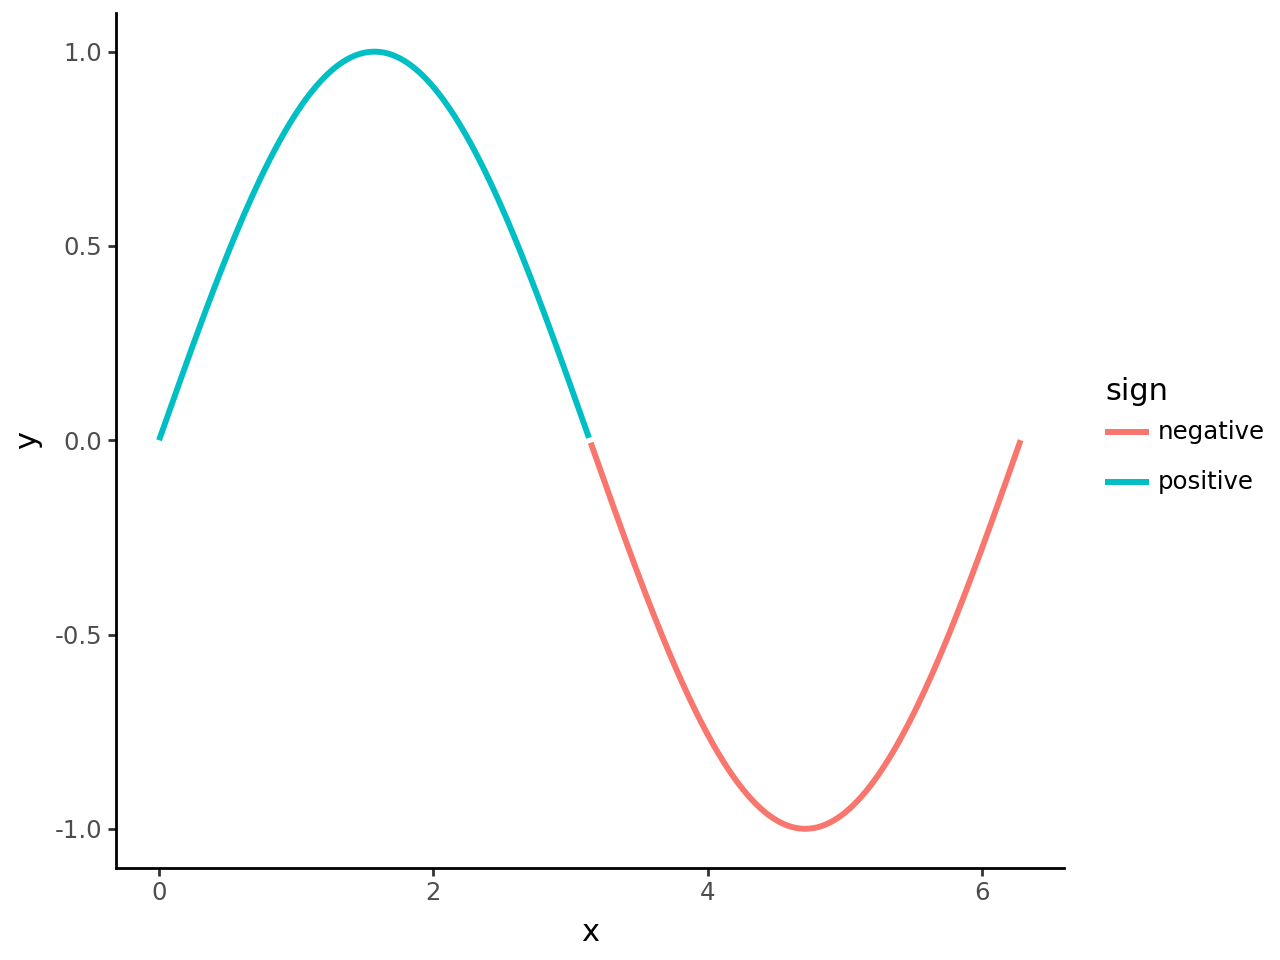

In [6]:
# works with plotnine
import numpy
from datar.base import sin, pi
from datar.tibble import tibble
from datar.dplyr import mutate, if_else
from plotnine import ggplot, aes, geom_line, theme_classic

df = tibble(x=numpy.linspace(0, 2 * pi, 500))
(
    df
    >> mutate(y=sin(f.x), sign=if_else(f.y >= 0, "positive", "negative"))
    >> ggplot(aes(x="x", y="y"))
    + theme_classic()
    + geom_line(aes(color="sign"), size=1.2)
)

In [7]:
# very easy to integrate with other libraries
# for example: klib

# Skipping this as klib uses pandas as backend

# import klib
# from pipda import register_verb
# from datar import f
# from datar.data import iris
# from datar.dplyr import pull

# dist_plot = register_verb(func=klib.dist_plot)
# iris >> pull(f.Sepal_Length) >> dist_plot()